Saving Iris.csv to Iris.csv
Accuracy: 1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



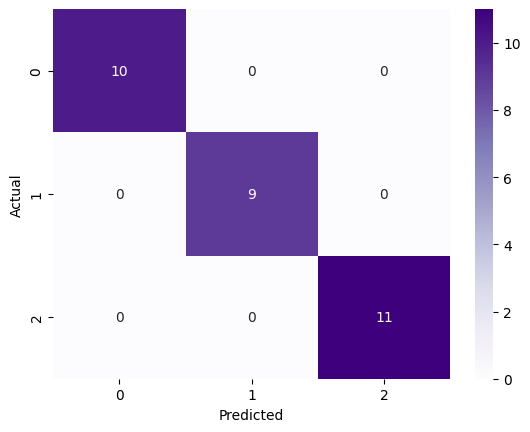

In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

if 'Id' in df.columns:
    df = df.drop('Id',axis=1)

X = df.drop('Species',axis=1)
y = df['Species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Saving Iris.csv to Iris (1).csv


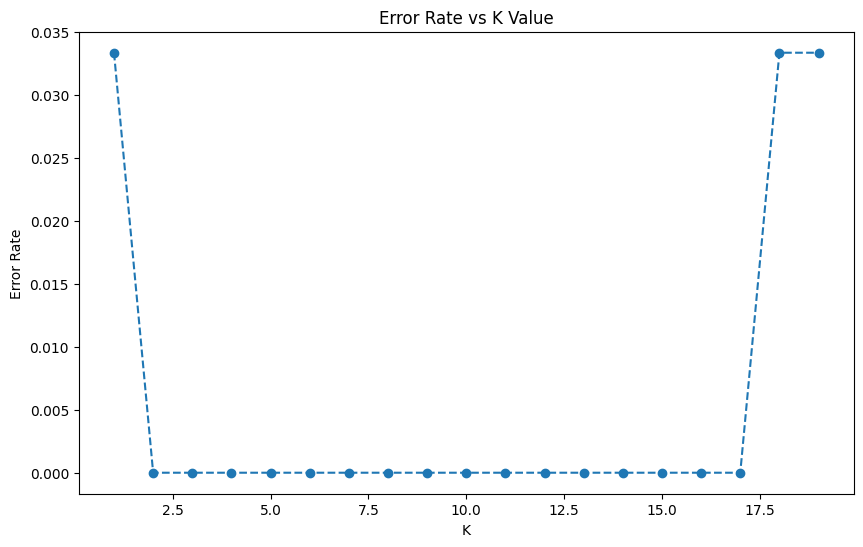

Optimal K: 2
Accuracy: 1.0


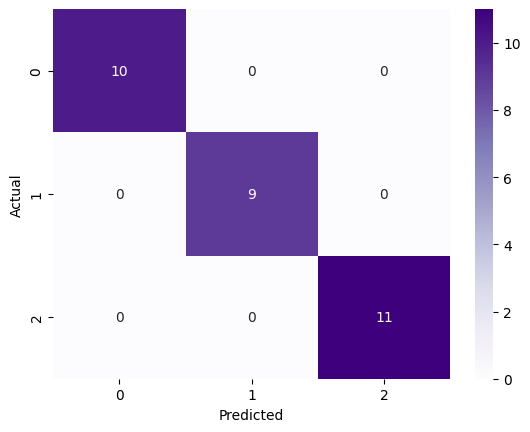

In [2]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

if 'Id' in df.columns:
    df = df.drop('Id',axis=1)

X = df.drop('Species',axis=1)
y = df['Species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

error_rate = []

for i in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,20),error_rate,linestyle='dashed',marker='o')
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.title("Error Rate vs K Value")
plt.show()

optimal_k = error_rate.index(min(error_rate)) + 1

print("Optimal K:",optimal_k)

model = KNeighborsClassifier(n_neighbors=optimal_k)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()